## **K-Means Algorithm in 3D**

### **Topic Roadmap**

**1. Load three real features**

**2. Fit K-Means in three dimensions**

**3. Visualize clusters and centroids**

**4. Inspect assignments**

**5. Key revision notes**

## **1. Three-Dimensional Dataset**

The first three Iris measurements provide a real three-feature dataset for a 3D K-Means visualization.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

RANDOM_STATE = 42
iris = load_iris(as_frame=True)
X_raw = iris.data.iloc[:, :3]
X = StandardScaler().fit_transform(X_raw)
features = list(X_raw.columns)
features

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)']

## **2. Fit K-Means**

Standardization prevents the feature with the largest numeric scale from dominating Euclidean distance.

In [4]:
kmeans = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE)
labels = kmeans.fit_predict(X)
print("Inertia:", kmeans.inertia_)

Inertia: 119.1390151661146


## **3. 3D Visualization**

The centroids are shown as black crosses in the standardized feature space.

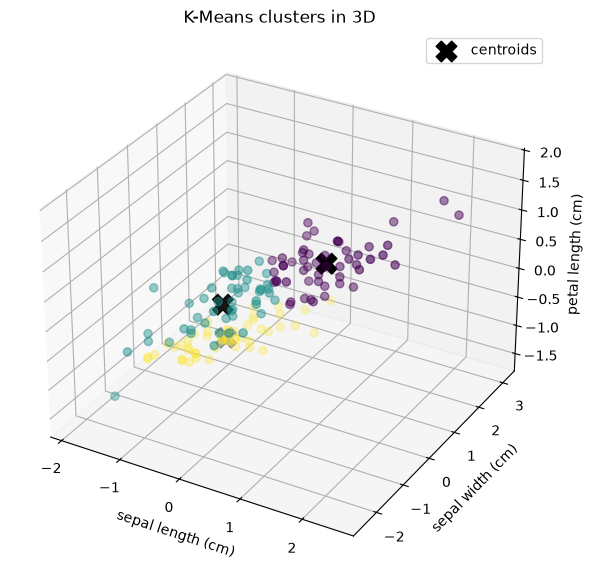

In [5]:
fig = plt.figure(figsize=(10, 7))
axis = fig.add_subplot(111, projection="3d")
axis.scatter(X[:, 0], X[:, 1], X[:, 2], c=labels, cmap="viridis", s=35, alpha=0.8)
axis.scatter(
    kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], kmeans.cluster_centers_[:, 2],
    c="black", marker="X", s=220, label="centroids"
)
axis.set_xlabel(features[0])
axis.set_ylabel(features[1])
axis.set_zlabel(features[2])
axis.set_title("K-Means clusters in 3D")
axis.legend()
plt.show()

In [6]:
cluster_summary = iris.data.copy()
cluster_summary["cluster"] = labels
cluster_summary.groupby("cluster").mean(numeric_only=True)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
cluster,,,,
0,6.742308,3.075000,5.426923,1.917308
1,5.716327,2.644898,4.279592,1.391837
2,5.016327,3.451020,1.465306,0.244898


### **Key Revision Notes**

- K-Means uses Euclidean distance, so feature scaling is important.
- A 3D plot shows only three features; the fitted model uses exactly those three here.
- Centroids are means in the transformed feature space.
- Use a metric such as silhouette score alongside a visualization.